<a href="https://colab.research.google.com/github/tixomirof/mo2_team_colabs/blob/main/%D0%9C%D0%9E2_%D0%9A%D0%BE%D0%BC%D0%B0%D0%BD%D0%B4%D0%B02_%D0%9B%D0%B0%D0%B106_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Шапка

Проектная работа. Группа №2. Обучение с учителем: деревья решений, случайные леса.

Участники команды:

* Ибраева Асем Балташевна
* Киреева Анастасия Игоревна
* Рудин Валентин Константинович
* Тихомиров Алексей Константинович


# Деревья решений - Decision Trees

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
df = pd.read_csv('/content/Engineered_Data.csv')
df.head()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Age_>35,Accessibility_Yes,EdLevel_NoHigherEd,EdLevel_Other,EdLevel_PhD,EdLevel_Undergraduate,Gender_NonBinary,Gender_Woman,MentalHealth_Yes,MainBranch_NotDev
0,1,7.0,4,51552.0,4,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,12.0,5,46482.0,12,1,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
2,1,15.0,6,77290.0,7,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,9.0,6,46135.0,13,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
4,0,40.0,30,160932.0,2,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,True


In [6]:
df['Employed'].value_counts()

,count
Employed,
1,37301
0,32385


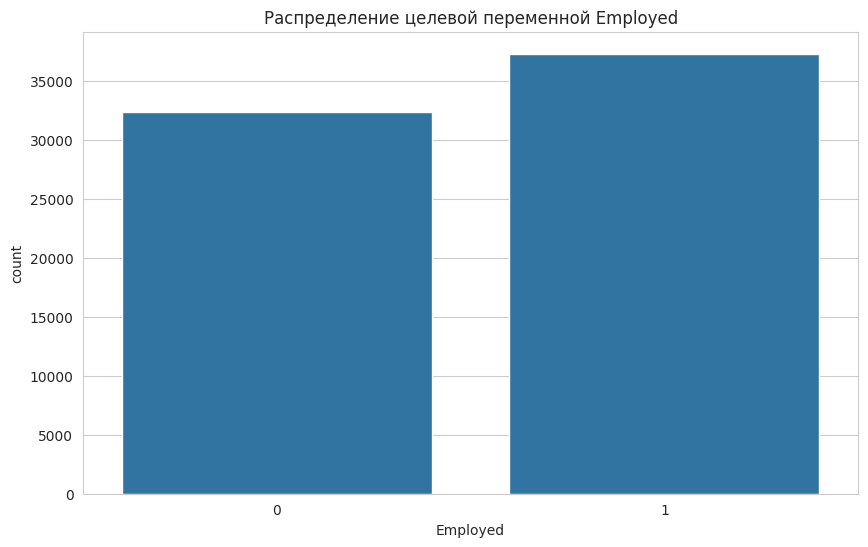

In [7]:
sns.countplot(data=df, x='Employed')
plt.title('Распределение целевой переменной Employed')
plt.show()

Можно заметить, что классы остаются достаточно сбалансированными, поэтому дерево решений можно обучать без дополнительных методов балансировки.

## Визуализация

Так как датасет достаточно большой, для графиков возьмем случайную выборку из 1000 строк. Это позволит быстрее построить визуализации и при этом сохранить общую картину распределений.


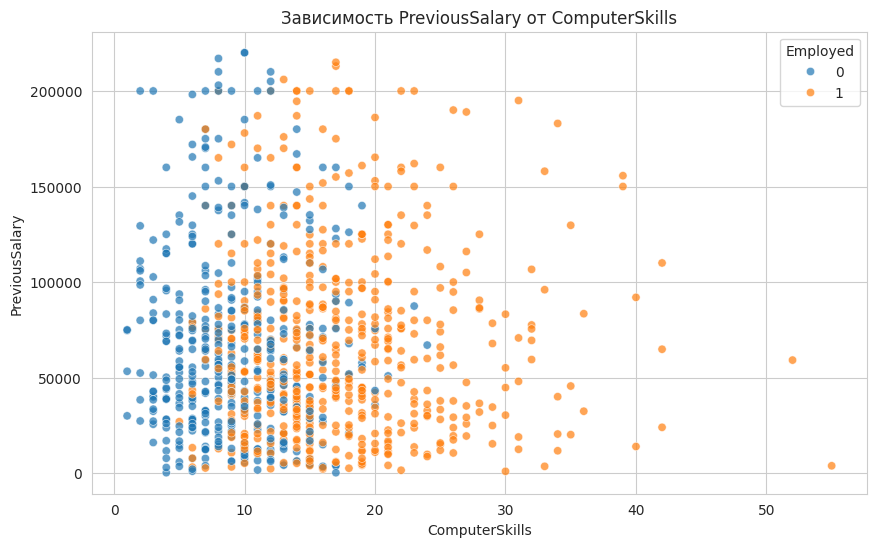

In [8]:
viz_sample = df[['YearsCode', 'YearsCodePro', 'PreviousSalary', 'ComputerSkills', 'gdp', 'Employed']].sample(1000, random_state=101)

sns.scatterplot(x='ComputerSkills', y='PreviousSalary', data=viz_sample, hue='Employed', alpha=0.7)
plt.title('Зависимость PreviousSalary от ComputerSkills')
plt.show()

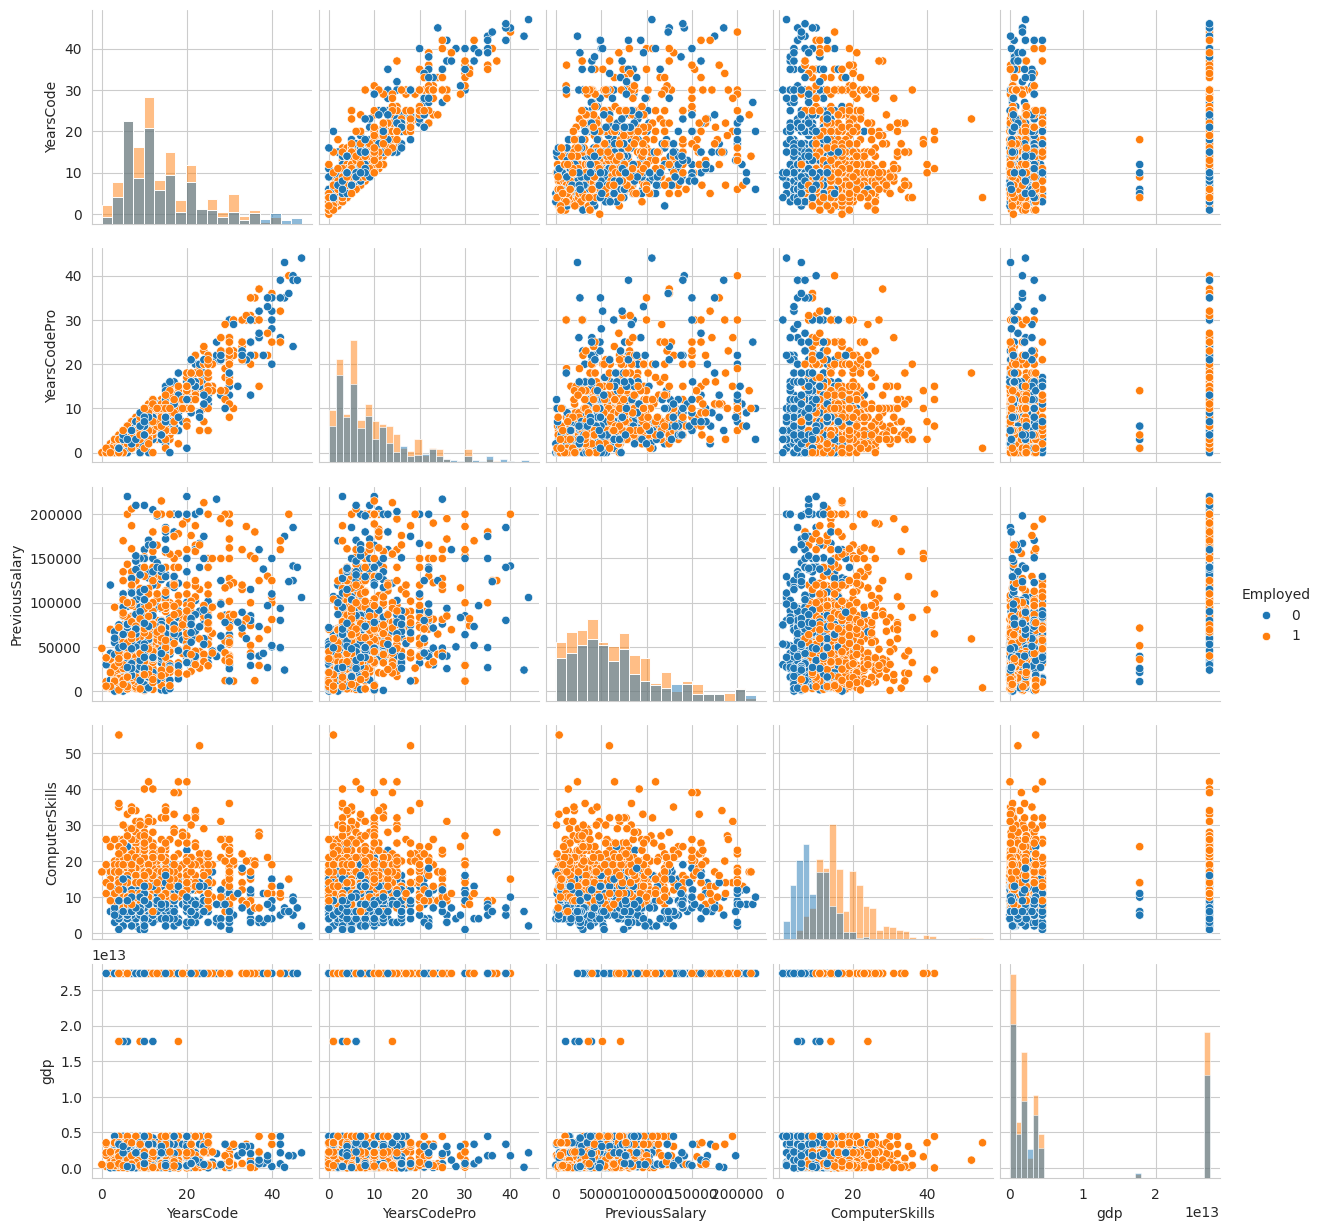

In [9]:
sns.pairplot(viz_sample, hue='Employed', diag_kind='hist')
plt.show()

По графикам заметно, что лучше всего классы снова разделяются по признаку `ComputerSkills`. Также некоторую роль играют `PreviousSalary` и `YearsCodePro`, однако разделение по ним уже не такое явное.

## Разбиение на обучающий и тестовый наборы данных - Train | Test Split

Разделим данные на признаки `X` и целевую переменную `y`, затем разобьем их на обучающую и тестовую выборки в отношении 70/30.

In [10]:
X = df.drop('Employed', axis=1)
y = df['Employed']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101
)

# Классификатор "Дерево решений" - Decision Tree Classifier

## Гиперпараметры по умолчанию

In [12]:
model = DecisionTreeClassifier(random_state=101)

In [13]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

In [14]:
base_pred = model.predict(X_test)

## Оценка работы модели

In [15]:
accuracy_score(y_test, base_pred)

0.9969386778915144

In [16]:
confusion_matrix(y_test, base_pred)

array([[ 9647,    43],
       [   21, 11195]])

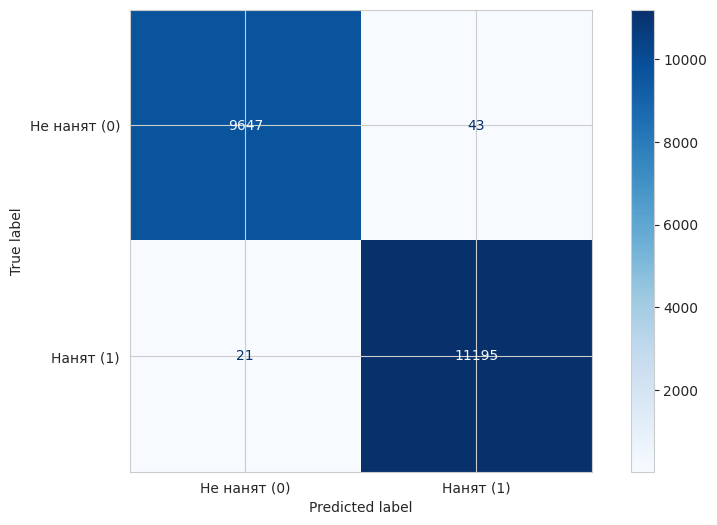

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    base_pred,
    display_labels=['Не нанят (0)', 'Нанят (1)'],
    cmap='Blues'
)
plt.show()

In [18]:
print(classification_report(y_test, base_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9690
           1       1.00      1.00      1.00     11216

    accuracy                           1.00     20906
   macro avg       1.00      1.00      1.00     20906
weighted avg       1.00      1.00      1.00     20906



Из-за округлений `classification_report` выдает 100%. По факту там не 100%.

In [19]:
model.get_depth(), model.get_n_leaves()

(16, np.int64(459))

In [20]:
model.feature_importances_

array([5.38624043e-06, 2.60727458e-04, 2.71229309e-04, 2.81732498e-04,
       3.40818331e-01, 0.00000000e+00, 0.00000000e+00, 2.85099834e-04,
       0.00000000e+00, 1.85397249e-04, 1.86736237e-04, 1.46170833e-04,
       0.00000000e+00, 7.46784362e-02, 0.00000000e+00, 1.37105985e-05,
       5.16917790e-02, 1.45635048e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.16455659e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 2.62364266e-05, 3.61612670e-06,
       0.00000000e+00, 7.46386186e-05, 1.93643304e-06, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.09010630e-04, 7.61161516e-05, 0.00000000e+00, 4.10239924e-05,
       0.00000000e+00, 2.60520750e-05, 2.52197977e-05, 3.17834525e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.50186804e-06,
      

In [21]:
feature_importance = pd.DataFrame(
    index=X.columns,
    data=model.feature_importances_,
    columns=['Feature Importance']
).sort_values('Feature Importance', ascending=False)

feature_importance.head(15)

,Feature Importance
ComputerSkills,0.340818
Microsoft SQL Server,0.096577
Node.js,0.086488
Bash/Shell,0.074678
TypeScript,0.065982
jQuery,0.060609
SQLite,0.059599
Java,0.058321
npm,0.052907
C#,0.051692


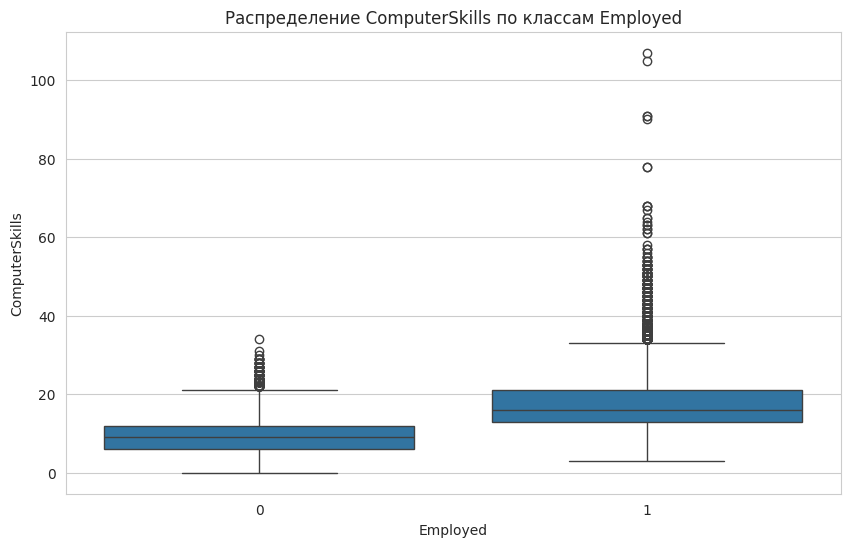

In [22]:
sns.boxplot(x='Employed', y='ComputerSkills', data=df)
plt.title('Распределение ComputerSkills по классам Employed')
plt.show()

Наиболее важным признаком оказался `ComputerSkills`. Это согласуется с предыдущими лабораторными работами, где именно этот признак сильнее всего коррелировал с фактом трудоустройства.

## Визуализация дерева

Полное дерево получилось довольно большим: глубина 16 и 459 листьев. Поэтому для читаемости отобразим только первые уровни дерева.


In [23]:
from sklearn.tree import plot_tree

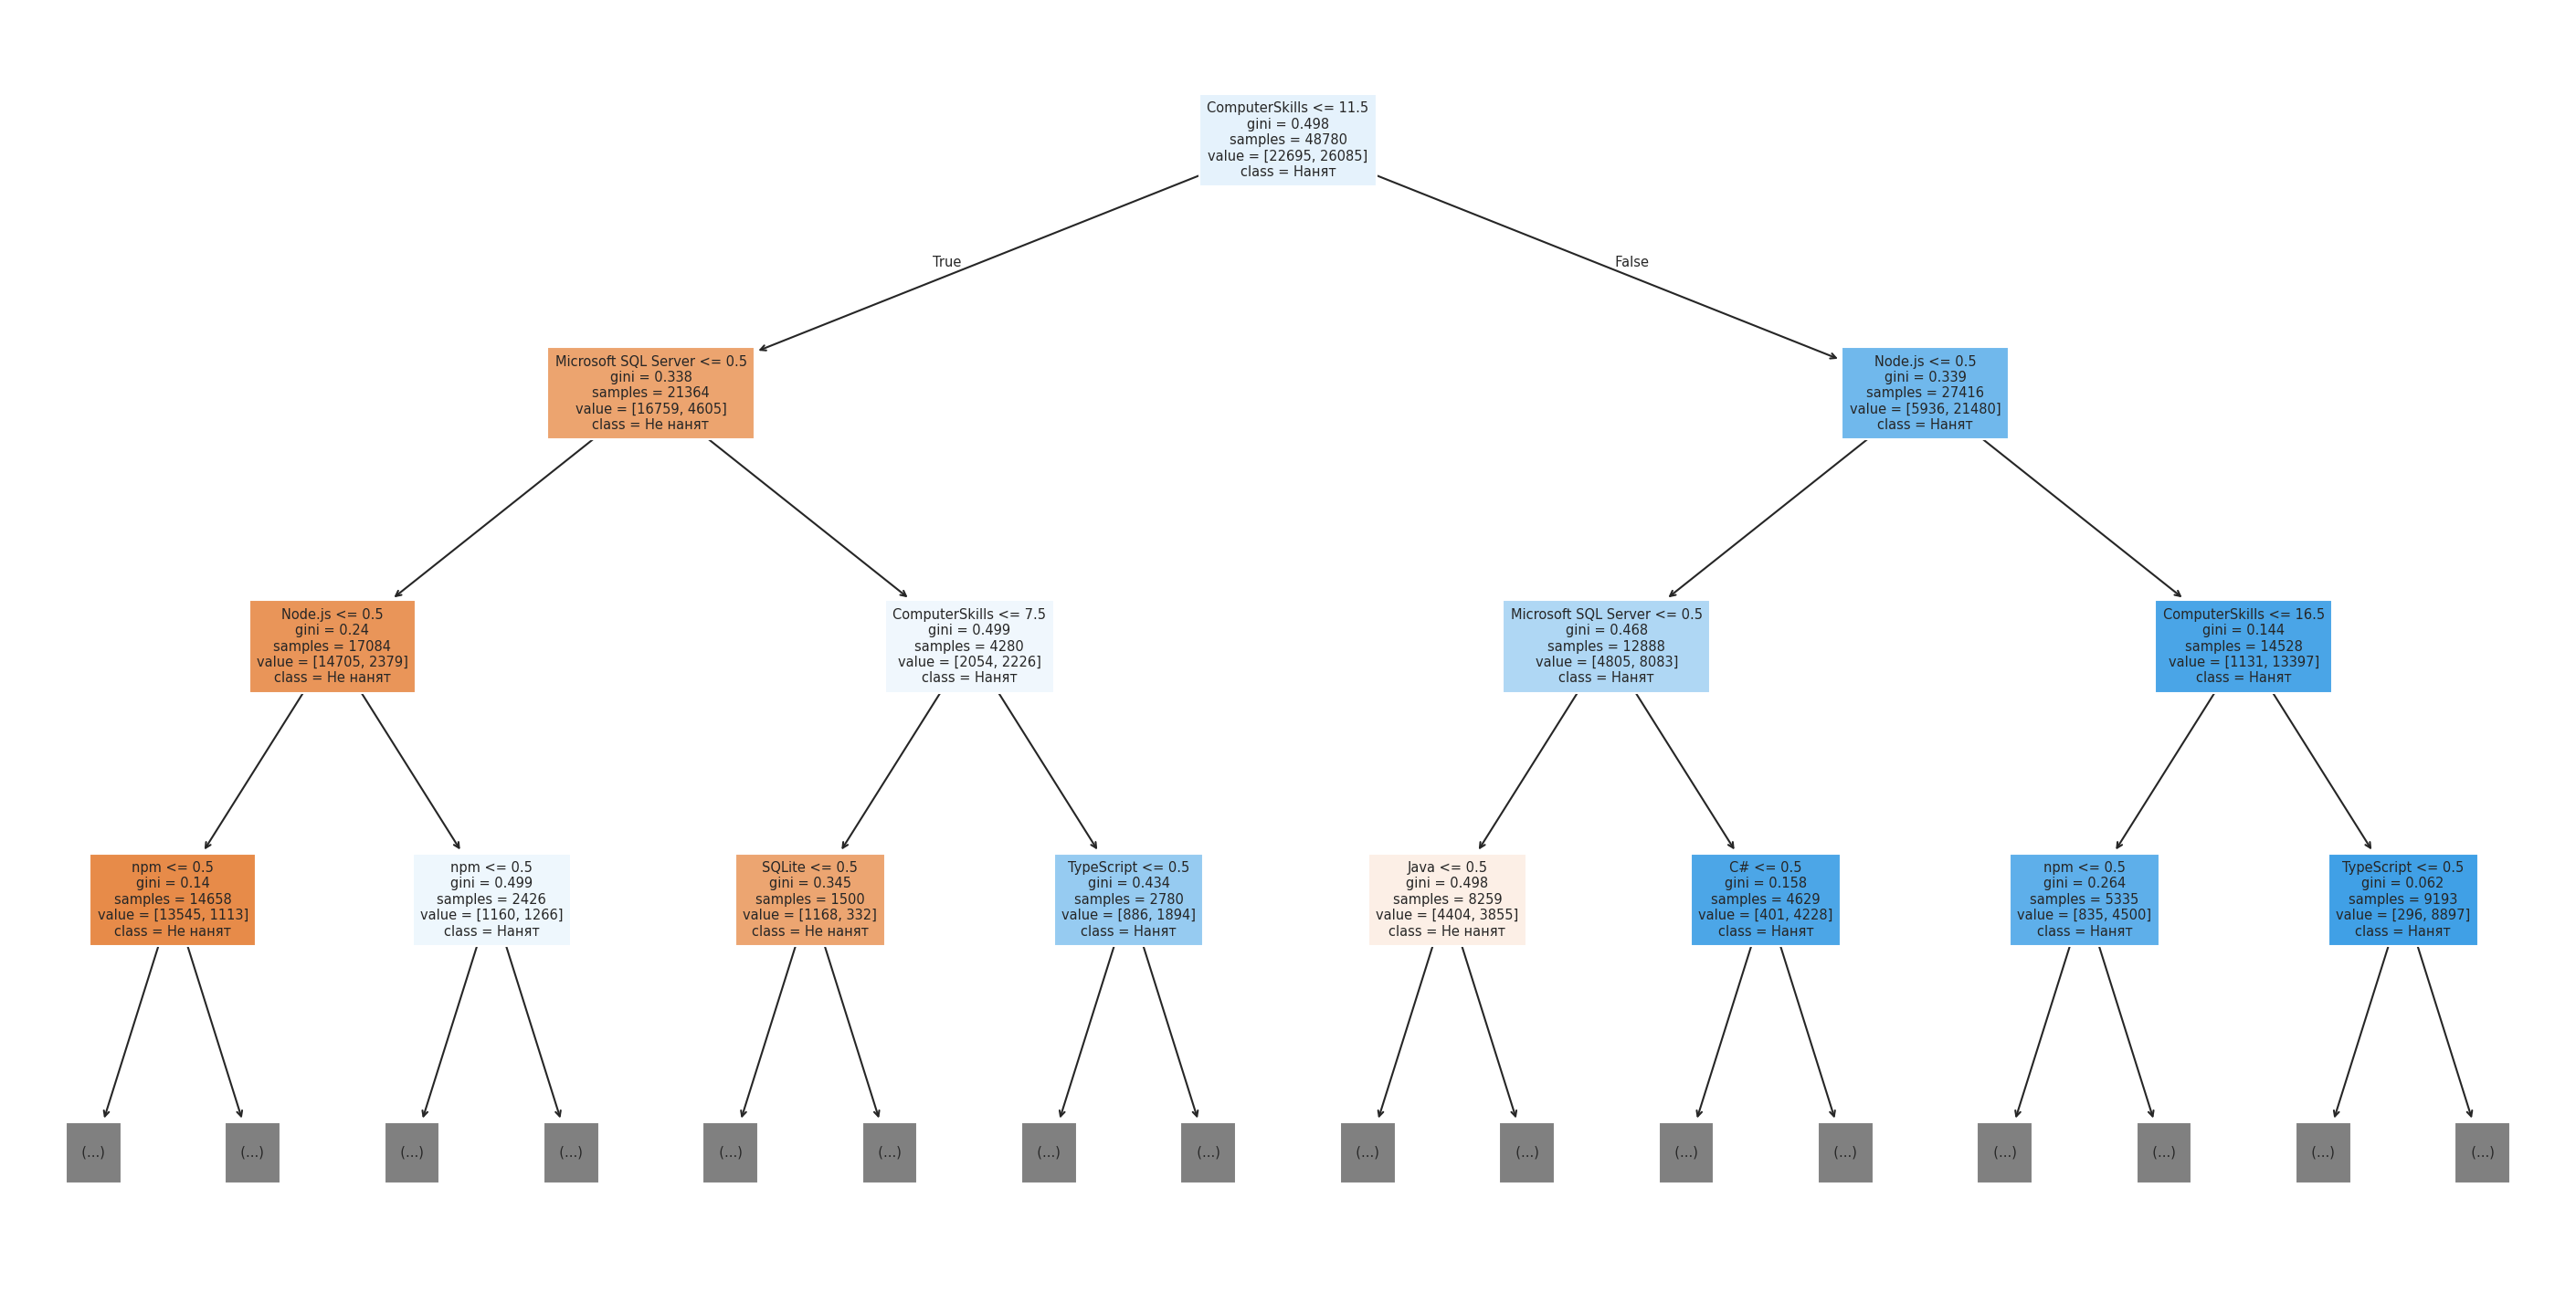

In [24]:
plt.figure(figsize=(24, 12), dpi=150)
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['Не нанят', 'Нанят'],
    max_depth=3,
    fontsize=7
)
plt.show()

## Результаты модели

Чтобы поэкспериментировать с гиперпараметрами, создадим функцию, которая выводит точность, classification report и рисует дерево.


In [25]:
def report_model(model, plot_depth=3):
    model_preds = model.predict(X_test)
    print(f'Accuracy: {accuracy_score(y_test, model_preds):.6f}')
    print(classification_report(y_test, model_preds))

    plt.figure(figsize=(24, 12), dpi=150)
    plot_tree(
        model,
        filled=True,
        feature_names=X.columns,
        class_names=['Не нанят', 'Нанят'],
        max_depth=plot_depth,
        fontsize=7
    )
    plt.show()

## Гиперпараметры

### Гиперпараметр "Max Depth"

In [26]:
DecisionTreeClassifier().get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [27]:
pruned_tree = DecisionTreeClassifier(max_depth=2, random_state=101)
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=101)

Accuracy: 0.785133
              precision    recall  f1-score   support

           0       0.86      0.64      0.73      9690
           1       0.75      0.91      0.82     11216

    accuracy                           0.79     20906
   macro avg       0.80      0.78      0.78     20906
weighted avg       0.80      0.79      0.78     20906



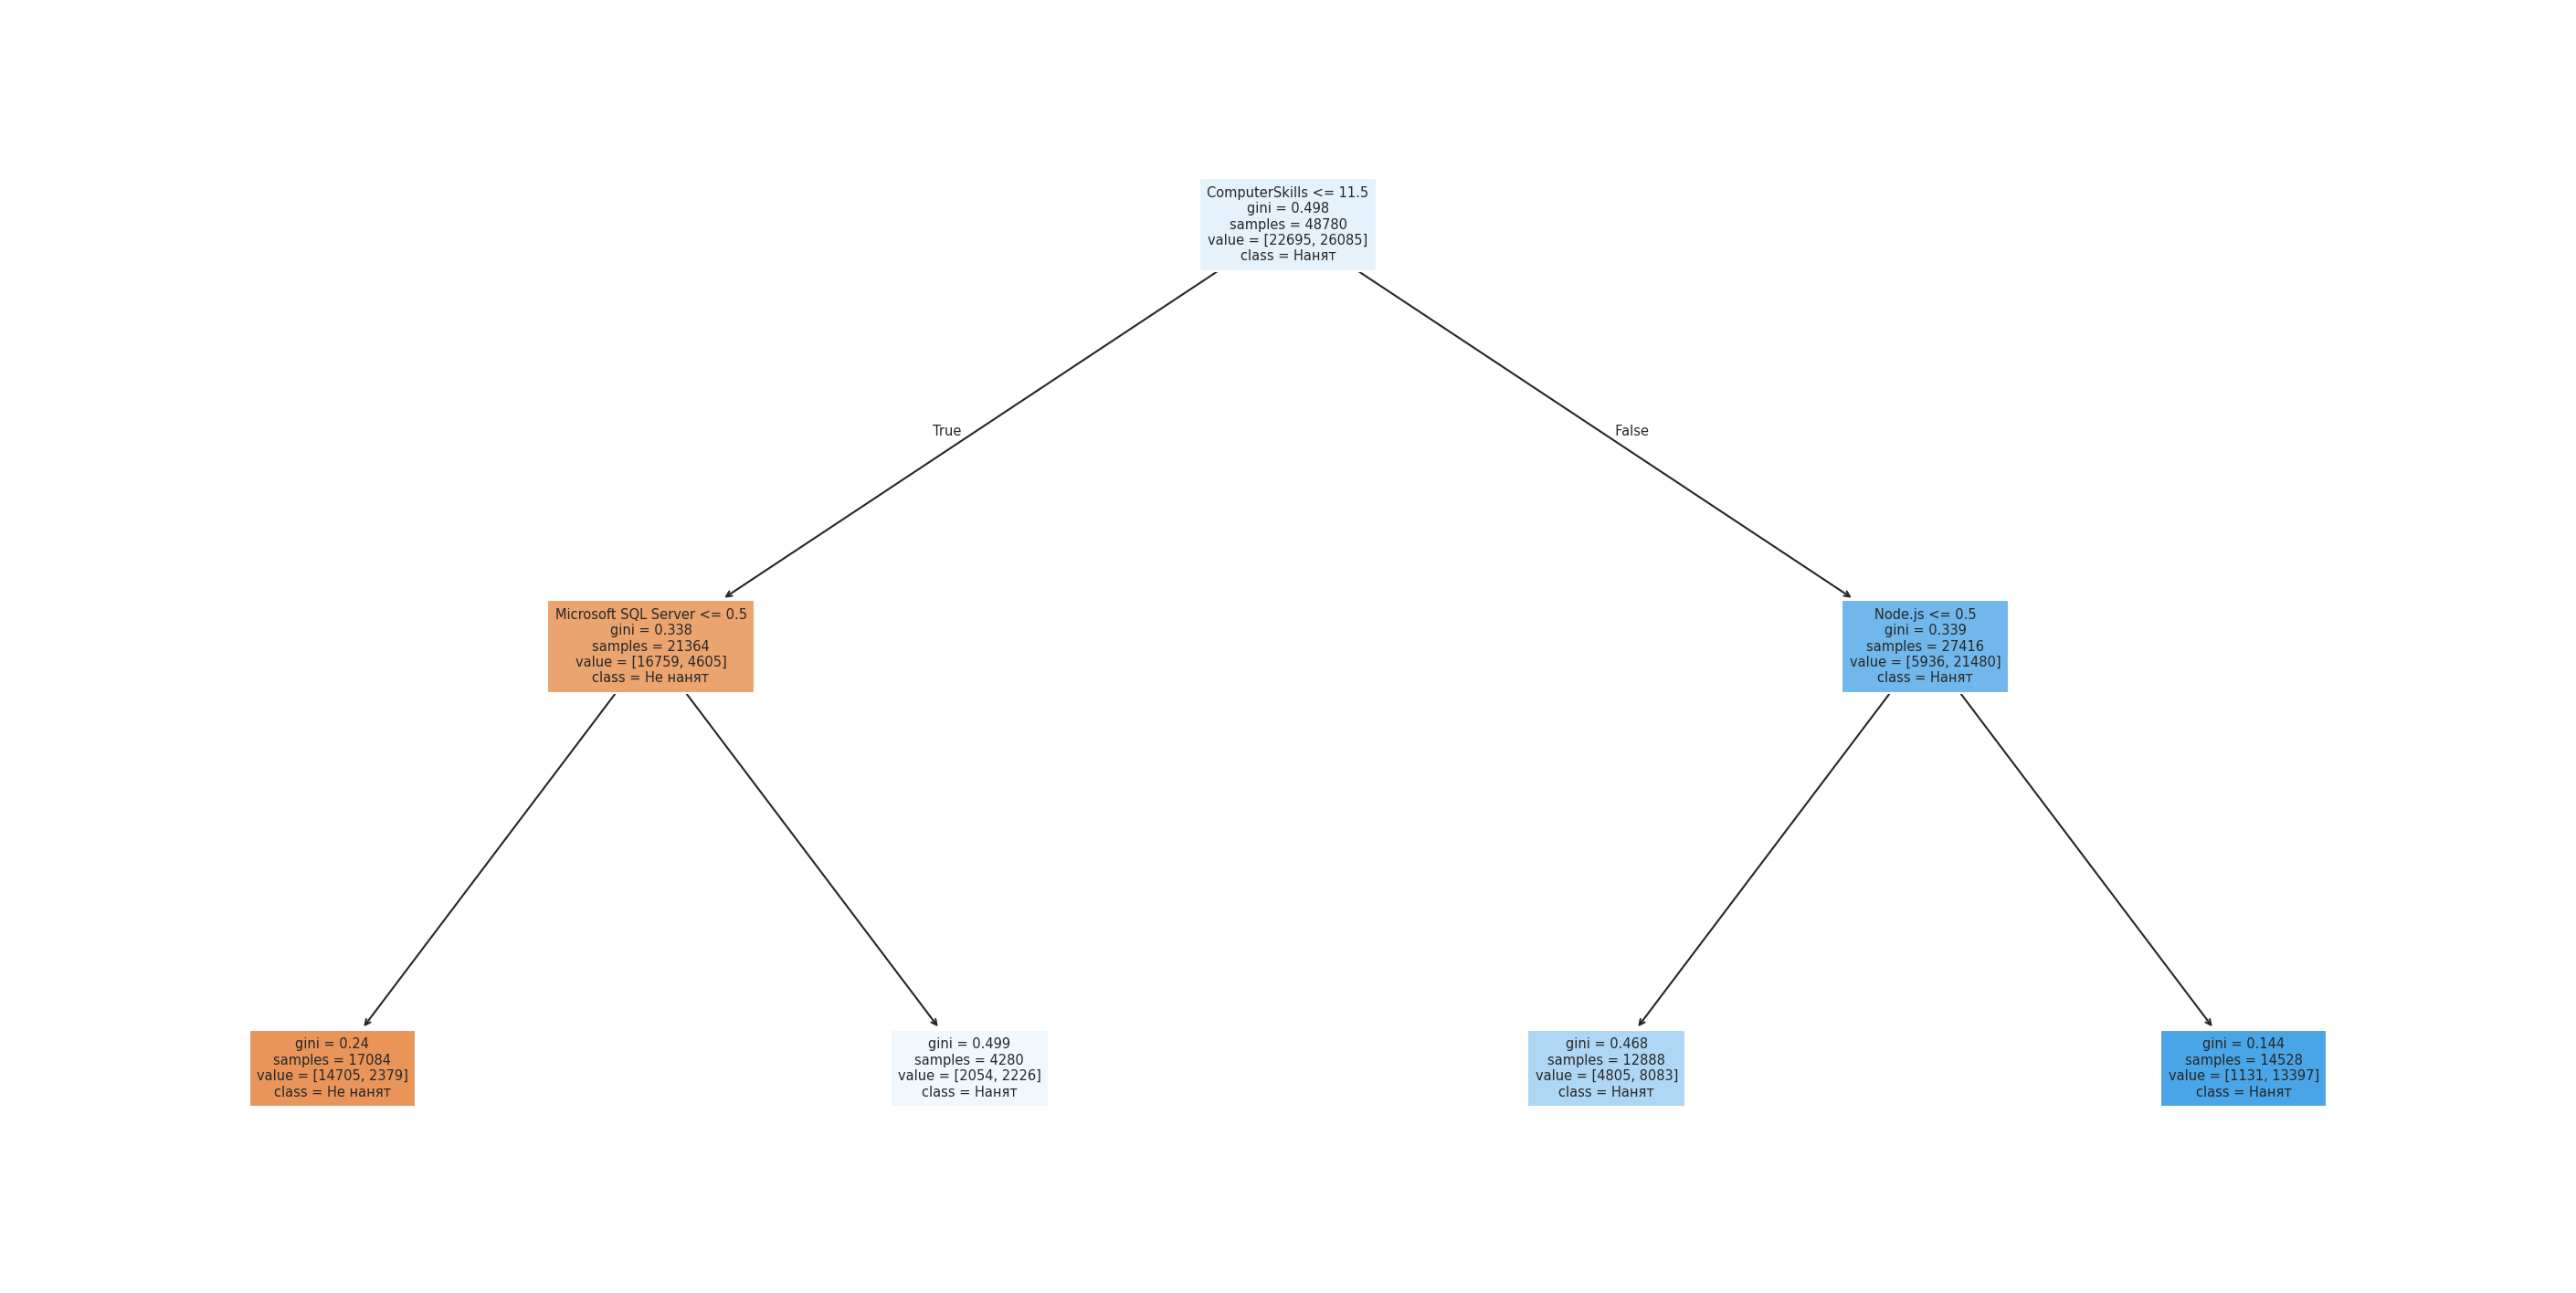

In [28]:
report_model(pruned_tree, plot_depth=2)

При слишком сильном ограничении глубины дерево начинает заметно терять качество. Для нашего датасета `max_depth=2` оказалось слишком маленьким значением.

## Гиперпараметр "Max Leaf Nodes"

In [29]:
leaf_tree = DecisionTreeClassifier(max_leaf_nodes=30, random_state=101)
leaf_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=30, random_state=101)

Accuracy: 0.889601
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      9690
           1       0.91      0.88      0.90     11216

    accuracy                           0.89     20906
   macro avg       0.89      0.89      0.89     20906
weighted avg       0.89      0.89      0.89     20906



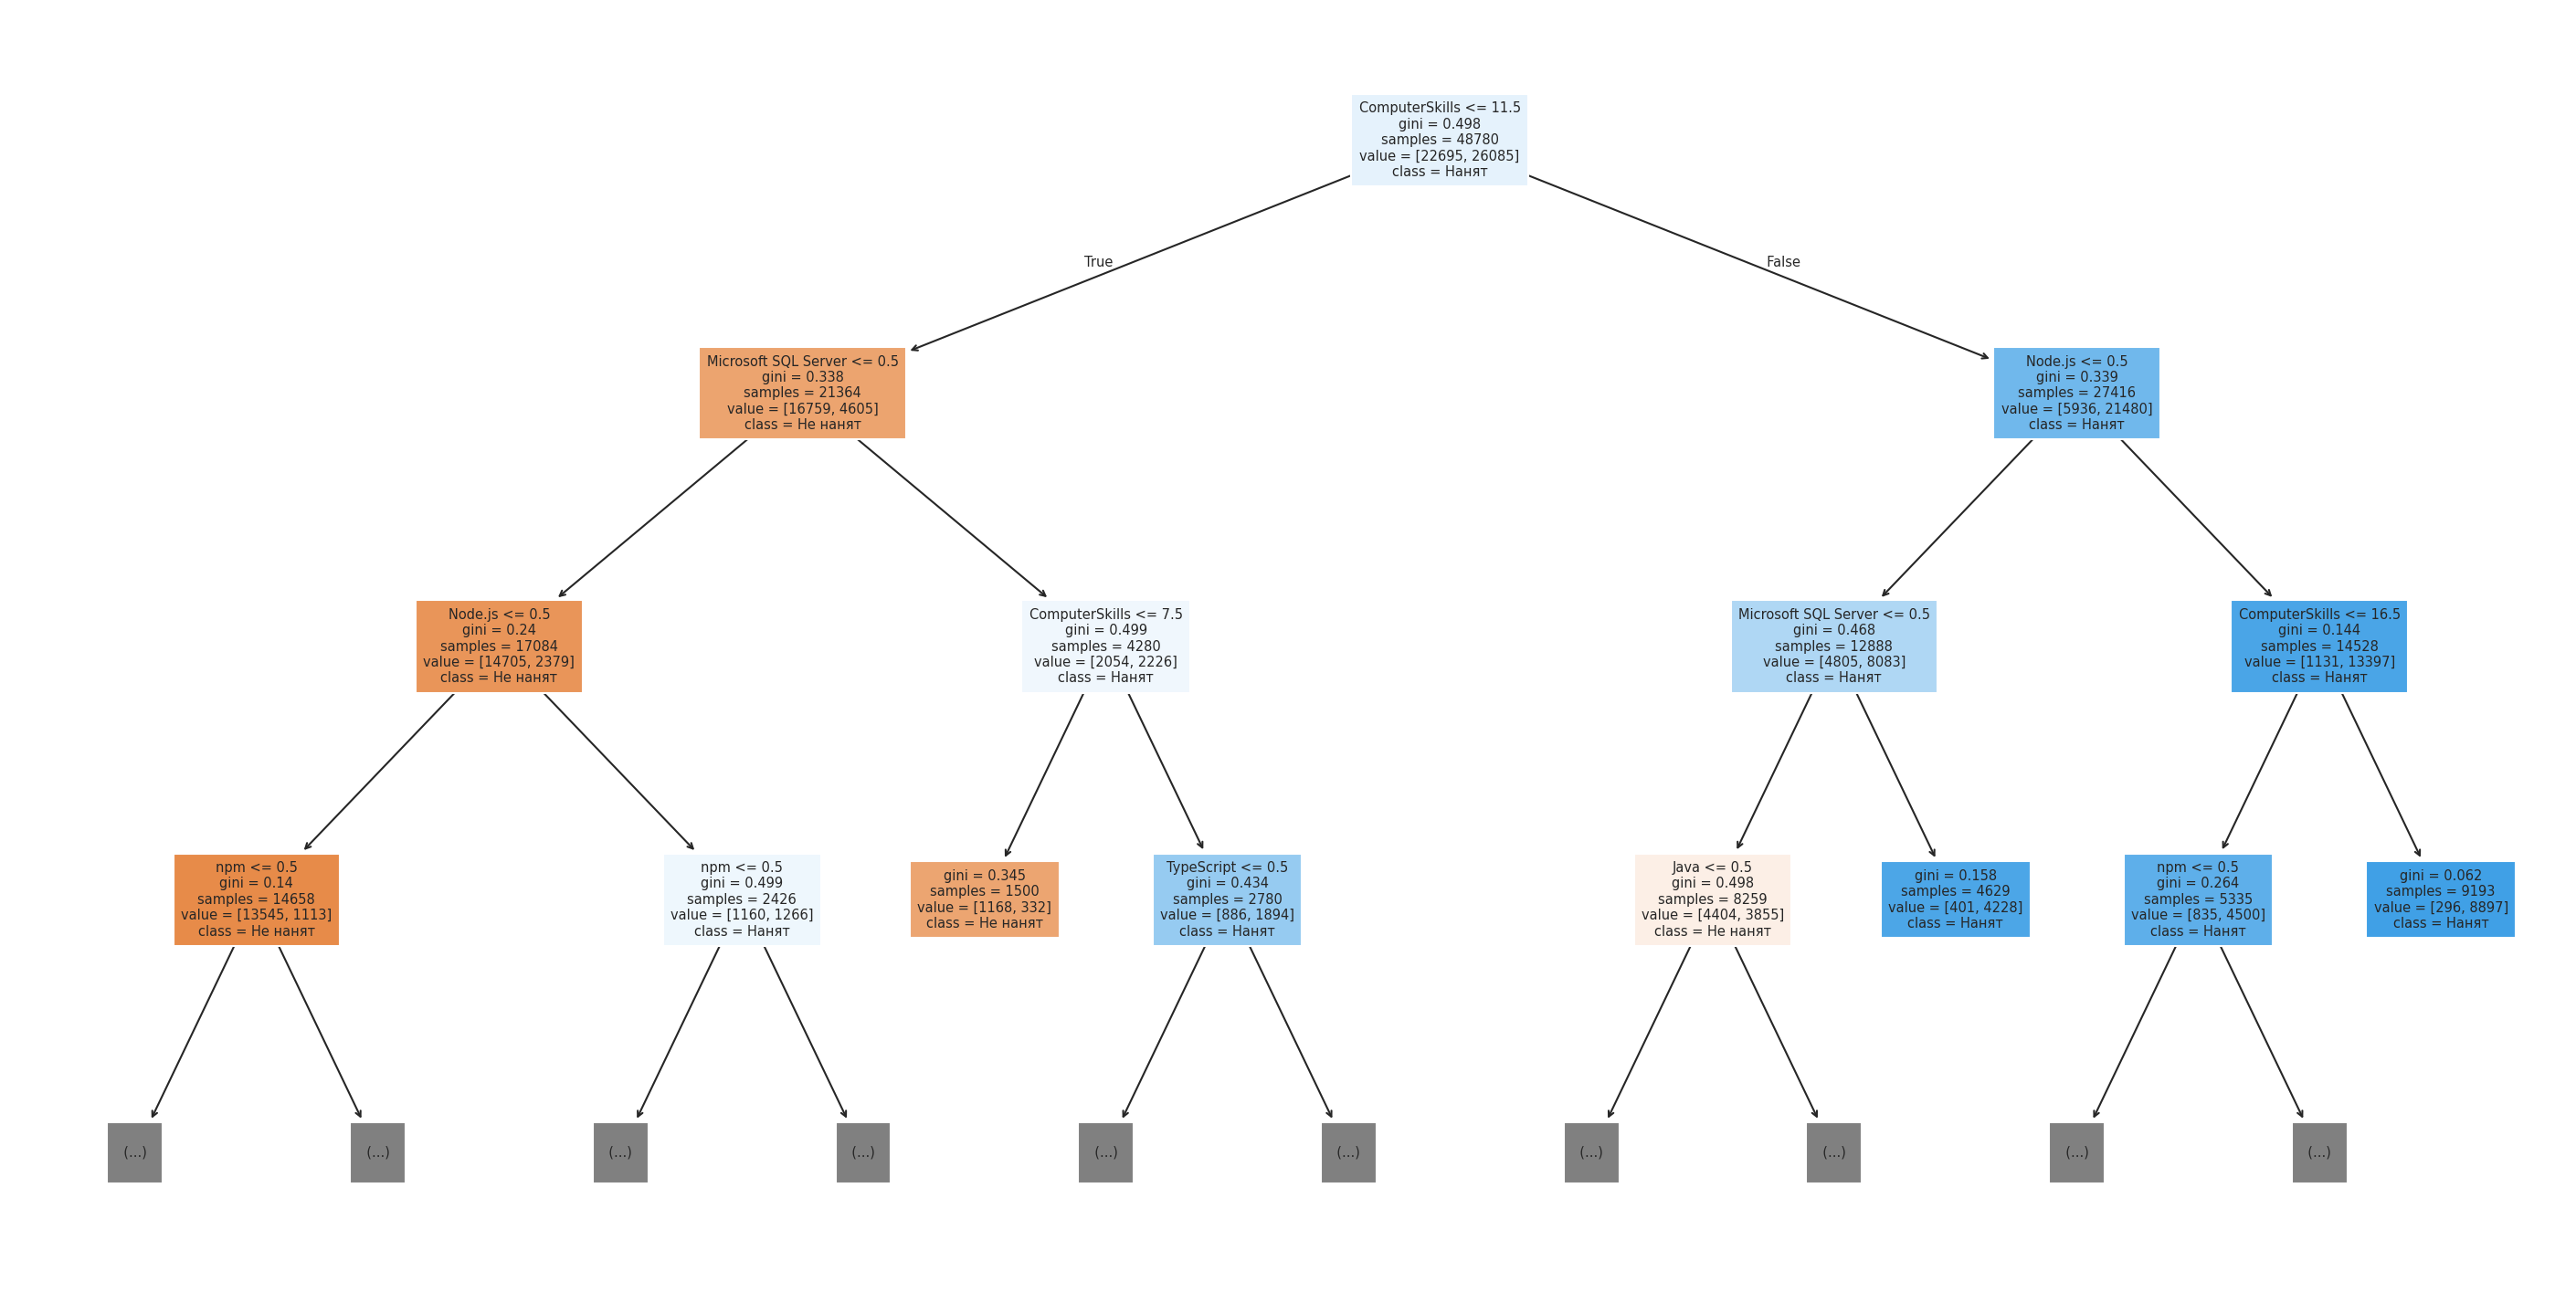

In [30]:
report_model(leaf_tree, plot_depth=3)

Ограничение числа листьев работает лучше, чем ограничение глубины до 2, однако при `max_leaf_nodes=30` модель все равно уступает полному дереву.

## Гиперпараметр "Criterion"

In [31]:
entropy_tree = DecisionTreeClassifier(criterion='entropy', random_state=101)
entropy_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=101)

Accuracy: 0.998182
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9690
           1       1.00      1.00      1.00     11216

    accuracy                           1.00     20906
   macro avg       1.00      1.00      1.00     20906
weighted avg       1.00      1.00      1.00     20906



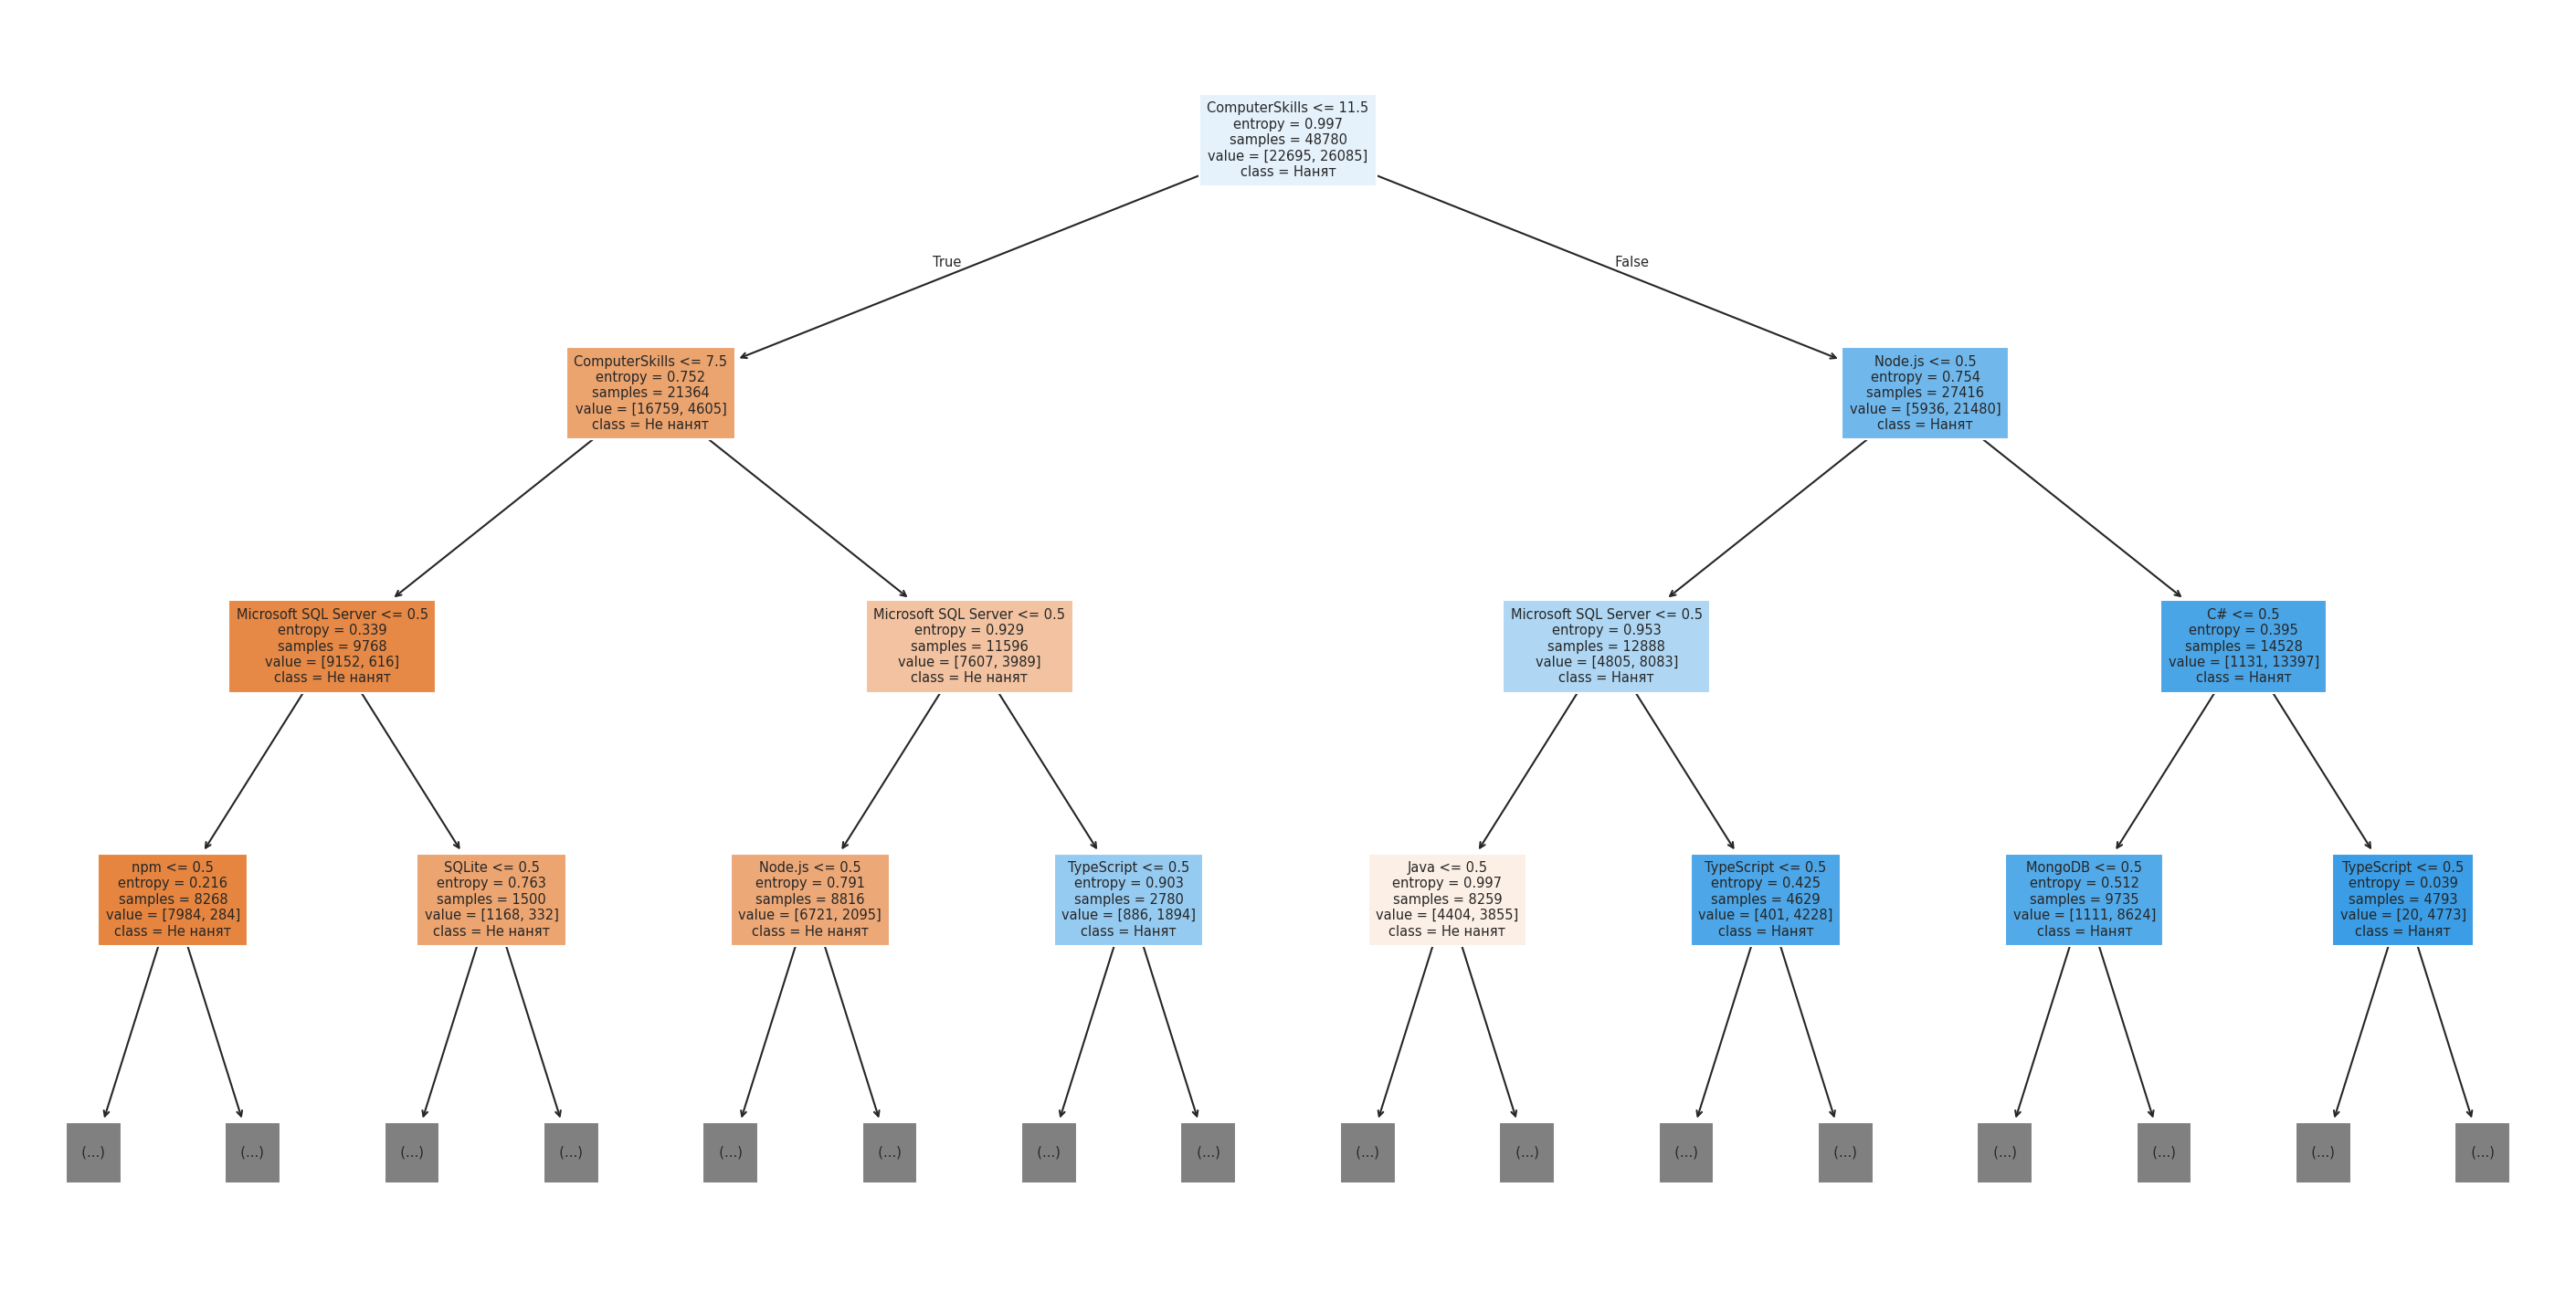

In [32]:
report_model(entropy_tree, plot_depth=3)

Использование полного дерева решений дало точность `0.9969`, а замена критерия на `entropy` немного улучшила результат до `0.9982`. Самым важным признаком остался `ComputerSkills`, что совпадает с результатами предыдущих лабораторных работ. Дерево решений показало результат лучше, чем KNN, но все же чуть хуже, чем логистическая регрессия и SVM, которые ранее дали 100% точности. В следующих разделах этого же ноутбука будут рассмотрены другие методы на основе деревьев.

# Случайный лес